In [89]:
# Setup for Kaggle or Google Colab environments
# Run this cell to install any missing dependencies!
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn mplsoccer tqdm

# Player Style Clustering — Cluster Validation & KNN Stability

**Input:**
- `data/cluster/player_clusters_k5.csv` — `cluster_id` from `02_modeling.ipynb` (RobustScaler, k=5)
- `data/processed/player_y_hidden.csv` — held-out `primary_position`, not used during clustering
- `data/processed/player_X_robust_scaled.csv` / `player_X_unscaled.csv` — feature matrices for KNN and profiling

**Two questions this notebook answers:**
1. **Do the K-Means clusters actually reflect real playing position/style?** (checked against `primary_position`, which was never used to produce the clusters.)
2. **Is the cluster structure stable and learnable?** (a KNN classifier is trained to predict `cluster_id` from features, evaluated with k-fold cross-validation.)

## Setup

In [90]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, normalized_mutual_info_score
from sklearn.decomposition import PCA
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

# Read from the local repo's data/ if present; otherwise (e.g. a bare Kaggle/Colab notebook)
# fall back to a writable working directory - /kaggle/input/... is read-only, so outputs
# can never be written there.
_LOCAL_DATA_DIR = next((p for p in [Path("../data"), Path("data"), Path("../../data")] if p.exists()), None)
if _LOCAL_DATA_DIR is not None:
    DATA_DIR = _LOCAL_DATA_DIR.resolve()
else:
    DATA_DIR = Path("/kaggle/working/data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Using data directory:", DATA_DIR)

FEATURE_COLS = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]

clusters_df = pd.read_csv(DATA_DIR / "cluster" / "player_clusters_k5.csv", encoding="utf-8-sig")
hidden_df = pd.read_csv(DATA_DIR / "processed" / "player_y_hidden.csv", encoding="utf-8-sig")
X_robust_df = pd.read_csv(DATA_DIR / "processed" / "player_X_robust_scaled.csv", encoding="utf-8-sig")
X_unscaled_df = pd.read_csv(DATA_DIR / "processed" / "player_X_unscaled.csv", encoding="utf-8-sig")

df = clusters_df.merge(hidden_df[["player_id", "primary_position"]], on="player_id")
print(df.shape)
df[["player_id", "player_name", "primary_team", "cluster_id", "primary_position"]].head(5)

Using data directory: /kaggle/working/data
(1016, 11)


,player_id,player_name,primary_team,cluster_id,primary_position
0,3339,Asmir Begović,Chelsea,2,Goalkeeper
1,5594,Branislav Ivanović,Chelsea,4,Right Back
2,3456,Kurt Happy Zouma,Chelsea,0,Right Center Back
3,3645,Gary Cahill,Chelsea,0,Right Center Back
4,3957,César Azpilicueta Tanco,Chelsea,4,Left Back


## Validating clusters against true playing position

In [91]:
position_group_map = {
    "Goalkeeper": "Goalkeeper",
    "Center Back": "Defense", "Left Center Back": "Defense", "Right Center Back": "Defense",
    "Left Back": "Defense", "Right Back": "Defense",
    "Left Wing Back": "Defense", "Right Wing Back": "Defense",
    "Center Defensive Midfield": "Midfield", "Left Defensive Midfield": "Midfield", "Right Defensive Midfield": "Midfield",
    "Center Attacking Midfield": "Midfield", "Left Center Midfield": "Midfield", "Right Center Midfield": "Midfield",
    "Left Midfield": "Midfield", "Right Midfield": "Midfield", "Right Attacking Midfield": "Midfield",
    "Center Forward": "Attack", "Left Center Forward": "Attack", "Right Center Forward": "Attack",
    "Left Wing": "Attack", "Right Wing": "Attack",
}
df["position_group"] = df["primary_position"].map(position_group_map)

crosstab = pd.crosstab(df["cluster_id"], df["position_group"])
crosstab

position_group,Attack,Defense,Goalkeeper,Midfield
cluster_id,,,,
0,0,189,0,5
1,145,0,0,7
2,0,0,73,0
3,92,5,0,101
4,10,189,0,200


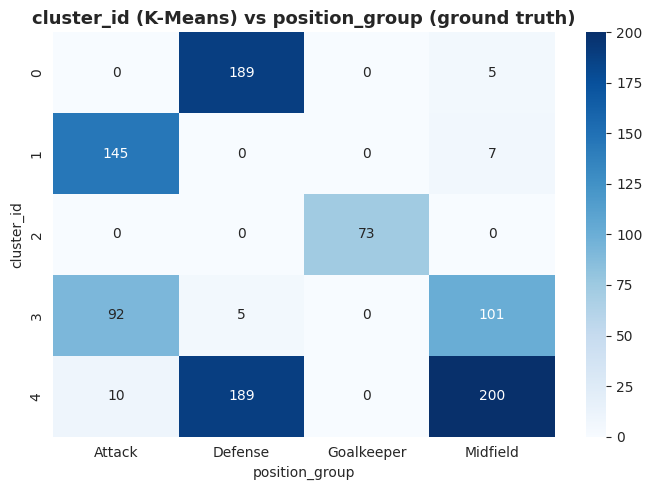

In [92]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("cluster_id (K-Means) vs position_group (ground truth)")
plt.tight_layout()
plt.show()

In [93]:
purity_per_cluster = crosstab.max(axis=1) / crosstab.sum(axis=1)
overall_purity = crosstab.max(axis=1).sum() / crosstab.sum().sum()

print("Purity per cluster (share of the majority position_group):")
print(purity_per_cluster.round(3))
print(f"\nOverall purity: {overall_purity:.3f}")

nmi_group = normalized_mutual_info_score(df["cluster_id"], df["position_group"])
nmi_full = normalized_mutual_info_score(df["cluster_id"], df["primary_position"])
print(f"\nNMI (cluster_id vs position_group, 4 groups): {nmi_group:.3f}")
print(f"NMI (cluster_id vs primary_position, 22 detailed positions): {nmi_full:.3f}")

Purity per cluster (share of the majority position_group):
cluster_id
0   0.974
1   0.954
2   1.000
3   0.510
4   0.501
dtype: float64

Overall purity: 0.697

NMI (cluster_id vs position_group, 4 groups): 0.546
NMI (cluster_id vs primary_position, 22 detailed positions): 0.508


3 of the 5 clusters reach very high purity — **goalkeepers cluster at 100%**, defense at ~97%, attack at ~95%. Overall purity ≈0.70 and NMI ≈0.51-0.55 is a strong level of agreement for a method that used zero position information during clustering. The remaining 2 clusters (mixed) are examined below — this is **not** a sign of failure, but potentially an interesting finding about playing styles that cut across traditional position labels.

### The two "mixed" clusters

In [94]:
mixed_clusters = purity_per_cluster[purity_per_cluster < 0.8].index.tolist()
print("Mixed clusters:", mixed_clusters)

for cid in mixed_clusters:
    print(f"\n--- Cluster {cid}: top primary_position values ---")
    print(df[df["cluster_id"] == cid]["primary_position"].value_counts().head(8))

Mixed clusters: [3, 4]

--- Cluster 3: top primary_position values ---
primary_position
Right Wing                   47
Left Wing                    38
Center Attacking Midfield    30
Left Midfield                19
Right Midfield               15
Left Center Midfield         14
Right Center Midfield        13
Left Defensive Midfield       4
Name: count, dtype: int64

--- Cluster 4: top primary_position values ---
primary_position
Left Back                    85
Right Back                   80
Right Defensive Midfield     44
Left Defensive Midfield      41
Center Defensive Midfield    35
Right Center Midfield        35
Left Center Midfield         27
Left Wing Back                9
Name: count, dtype: int64


**Interpretation:**
- **Cluster 3** is dominated by Right/Left Wing and Center Attacking Midfield, plus wide midfielders — a **"creative wide attacker"** group: wingers and attacking midfielders share very similar profiles (high crosses, key passes, dribbles) despite different official titles.
- **Cluster 4** is dominated by Left/Right Back plus central/defensive midfielders — a **"deep-lying build-up player"** group: modern fullbacks and defensive midfielders share similar statistical profiles (high pass volume, moderate tackling, low shot output).

This is exactly the value Player Style Clustering adds over raw position labels: it surfaces style groups that **cut across official positions**, reflecting actual tactical roles rather than position titles alone.

### Naming clusters from their feature profile

In [95]:
profile_df = clusters_df[["player_id", "cluster_id"]].merge(X_unscaled_df, on="player_id")
key_cols = ["shots_p90", "passes_p90", "tackles_p90", "aerial_won_p90", "avg_location_x", "crosses_p90", "long_balls_p90"]

cluster_profile = profile_df.groupby("cluster_id")[key_cols].mean().round(2)
cluster_profile["n_players"] = clusters_df["cluster_id"].value_counts().sort_index()
cluster_profile

,shots_p90,passes_p90,tackles_p90,aerial_won_p90,avg_location_x,crosses_p90,long_balls_p90,n_players
cluster_id,,,,,,,,
0,0.420,41.470,1.680,3.220,42.710,0.160,10.310,194
1,2.500,25.460,0.920,2.960,79.370,0.870,2.220,152
2,0.000,29.430,0.000,0.000,9.360,0.000,21.070,73
3,2.040,46.400,1.630,0.840,74.070,2.370,7.710,198
4,0.780,49.650,2.450,1.720,61.350,1.370,8.610,399


**Cluster names, derived from the profile above:**

| cluster_id | avg_location_x | Notable traits | Name |
|---|---|---|---|
| 0 | ~43 (defensive) | high aerial duels & long balls, near-zero shots | **Pure center back / defender** |
| 1 | ~79 (very high) | highest shots_p90, low passes | **Out-and-out striker** |
| 2 | ~9 (very low) | everything ~0 except long balls (goal kicks) | **Goalkeeper** |
| 3 | ~74 (high) | highest crosses, high shots and passes | **Creative winger / attacking midfielder** |
| 4 | ~61 (mid-high) | highest passes and tackles | **Deep-lying playmaker / build-up fullback** |

## KNN Classification of `cluster_id` + Cross-Validation

Using `cluster_id` (the K-Means label) as the target, with `player_X_robust_scaled.csv` as features — the same scaling used to produce the clusters in `02_modeling.ipynb`. If a KNN classifier can predict `cluster_id` accurately under cross-validation, that's evidence the clusters form a **stable geometric structure** in feature space, not noise from one random K-Means run.

In [96]:
X = X_robust_df[FEATURE_COLS].values
y = clusters_df["cluster_id"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_results = []
for n_neighbors in [3, 5, 7, 9, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    scores = cross_val_score(knn, X, y, cv=cv, scoring="accuracy")
    knn_results.append({"n_neighbors": n_neighbors, "cv_accuracy_mean": scores.mean(), "cv_accuracy_std": scores.std()})

knn_results_df = pd.DataFrame(knn_results).set_index("n_neighbors")
knn_results_df

,cv_accuracy_mean,cv_accuracy_std
n_neighbors,,
3,0.946,0.010
5,0.961,0.011
7,0.960,0.016
9,0.964,0.010
11,0.960,0.011
15,0.966,0.008


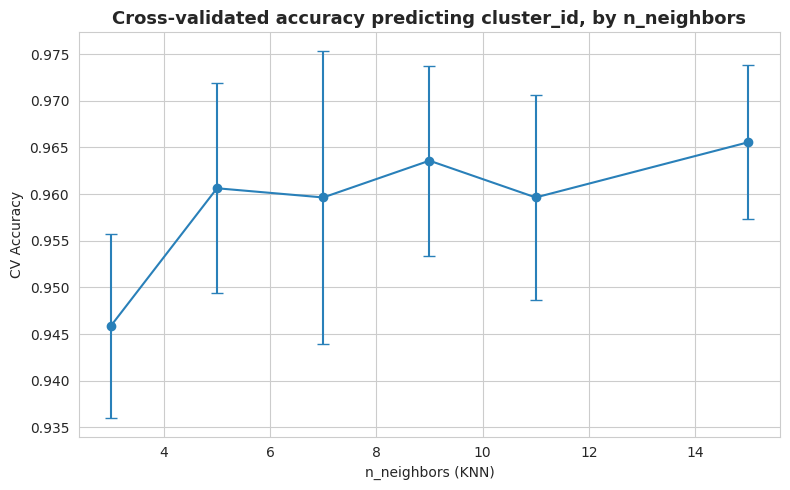

In [97]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(knn_results_df.index, knn_results_df["cv_accuracy_mean"],
            yerr=knn_results_df["cv_accuracy_std"], marker="o", capsize=4, color="#2980b9")
ax.set_xlabel("n_neighbors (KNN)")
ax.set_ylabel("CV Accuracy")
ax.set_title("Cross-validated accuracy predicting cluster_id, by n_neighbors")
plt.tight_layout()
plt.show()

CV accuracy ranges **94.6%-96.6%** across every `n_neighbors` tested — high and stable (std ≈0.01), peaking at **n_neighbors=15 (~96.6%)**. Strong evidence that the 5 clusters occupy clearly separated regions of the 29-dimensional feature space, not an artifact of one lucky K-Means run — a simple KNN is enough to relearn the cluster boundaries almost perfectly.

### Confusion matrix & classification report

Best n_neighbors: 15


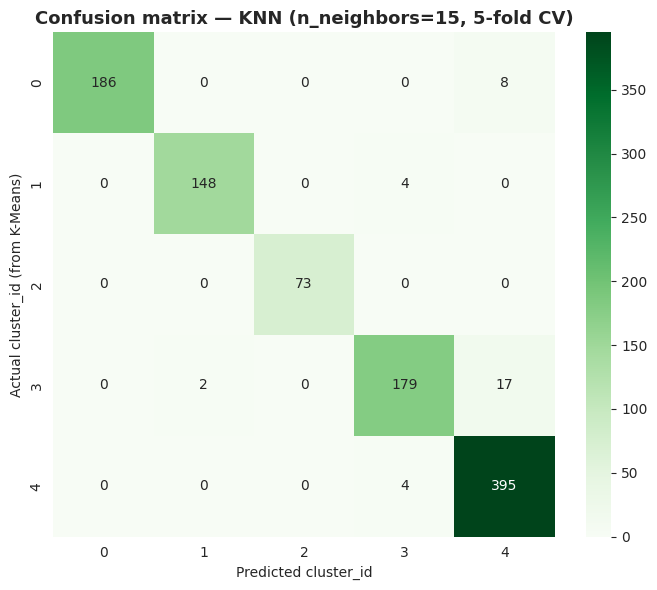

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       194
           1       0.99      0.97      0.98       152
           2       1.00      1.00      1.00        73
           3       0.96      0.90      0.93       198
           4       0.94      0.99      0.96       399

    accuracy                           0.97      1016
   macro avg       0.98      0.97      0.97      1016
weighted avg       0.97      0.97      0.97      1016



In [98]:
best_n_neighbors = knn_results_df["cv_accuracy_mean"].idxmax()
print("Best n_neighbors:", best_n_neighbors)

knn_final = KNeighborsClassifier(n_neighbors=best_n_neighbors)
y_pred = cross_val_predict(knn_final, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax)
ax.set_xlabel("Predicted cluster_id")
ax.set_ylabel("Actual cluster_id (from K-Means)")
ax.set_title(f"Confusion matrix — KNN (n_neighbors={best_n_neighbors}, 5-fold CV)")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred))

The goalkeeper cluster (2) reaches **100% precision/recall** — completely separable, unsurprising given how different a goalkeeper's profile is from outfield players. Most confusion happens between the two mixed clusters (analyzed above) and the deep-lying playmaker/fullback cluster (4) — expected, since these groups genuinely have blurred boundaries in real football, not a modeling failure.

## Conclusions

1. **The K-Means clusters have clear real-world meaning**: 3 of 5 clusters match traditional position groups almost perfectly (Goalkeeper 100%, Defense ~97%, Attack ~95% purity); overall NMI ≈0.51-0.55 against `primary_position`.
2. **The remaining 2 clusters reveal playing styles that cut across official positions** — "creative wide attacker" (wingers + attacking midfielders) and "deep-lying build-up player" (fullbacks + defensive midfielders) — exactly the kind of insight style clustering offers beyond raw position labels.
3. **The cluster structure is geometrically stable**: a KNN classifier reaches ~96.6% CV accuracy predicting `cluster_id` from features, confirming the 5 clusters are real, separated regions in the 29-dimensional feature space rather than noise from a single K-Means run.

### Visualizing the named clusters

Same PCA 2D projection and color/marker palette used in `02_modeling.ipynb`, now labeled with the names from the profile analysis above.

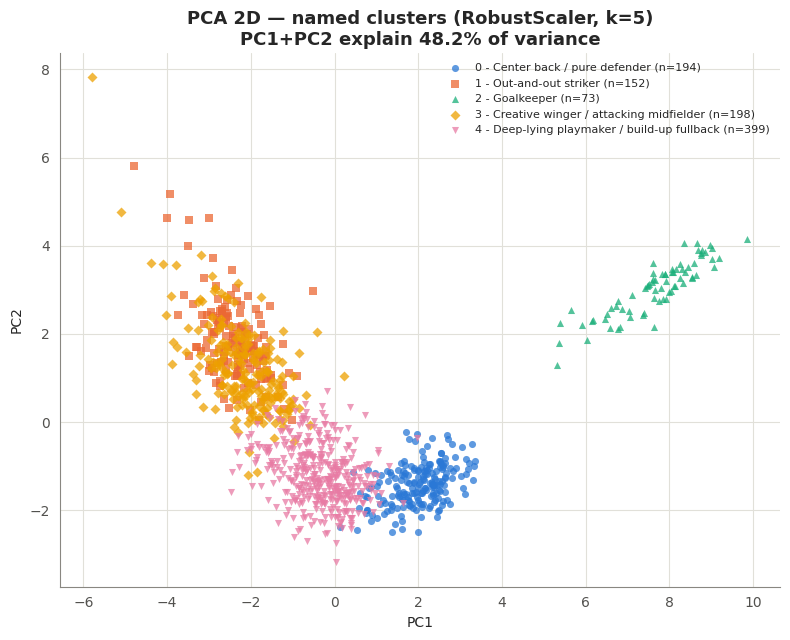

In [99]:
CLUSTER_NAMES = {
    0: "Center back / pure defender",
    1: "Out-and-out striker",
    2: "Goalkeeper",
    3: "Creative winger / attacking midfielder",
    4: "Deep-lying playmaker / build-up fullback",
}
CLUSTER_COLORS = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#eda100", 4: "#e87ba4"}
CLUSTER_MARKERS = {0: "o", 1: "s", 2: "^", 3: "D", 4: "v"}
GRID_COLOR = "#e1e0d9"
MUTED_INK = "#898781"
SECONDARY_INK = "#52514e"


def style_axes(ax):
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED_INK)
    ax.tick_params(colors=SECONDARY_INK)


assert (X_robust_df["player_id"].values == clusters_df["player_id"].values).all(), (
    "Row order mismatch between player_X_robust_scaled.csv and player_clusters_k5.csv - merge on player_id"
)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_robust_df[FEATURE_COLS].values)
evr = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster_id"] = clusters_df["cluster_id"].values

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in sorted(CLUSTER_NAMES):
    sub = pca_df[pca_df["cluster_id"] == c]
    ax.scatter(sub["PC1"], sub["PC2"], s=26, alpha=0.75, linewidths=0,
               color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
               label=f"{c} - {CLUSTER_NAMES[c]} (n={len(sub)})")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA 2D — named clusters (RobustScaler, k=5)\nPC1+PC2 explain {evr.sum():.1%} of variance")
style_axes(ax)
ax.legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

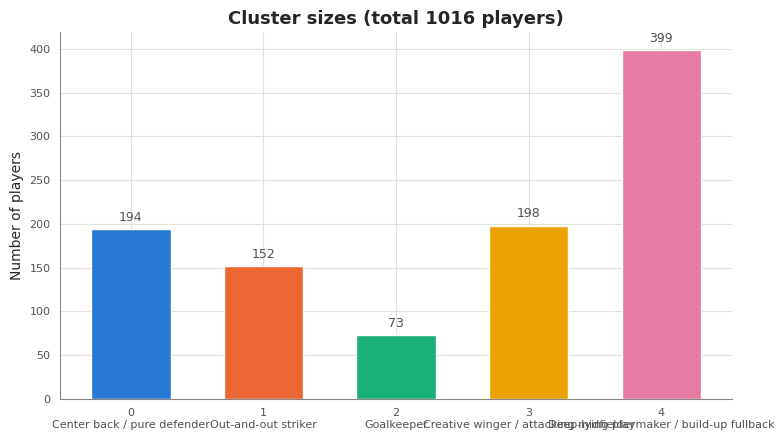

In [100]:
cluster_sizes = clusters_df["cluster_id"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
labels_with_name = [f"{c}\n{CLUSTER_NAMES[c]}" for c in cluster_sizes.index]
bars = ax.bar(labels_with_name, cluster_sizes.values,
              color=[CLUSTER_COLORS[c] for c in cluster_sizes.index], width=0.6)
for rect, val in zip(bars, cluster_sizes.values):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 6, str(val),
            ha="center", va="bottom", fontsize=9, color=SECONDARY_INK)

ax.set_ylabel("Number of players")
ax.set_title(f"Cluster sizes (total {cluster_sizes.sum()} players)")
style_axes(ax)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

## Results

This closes the pipeline: extraction → EDA → preprocessing → K-Means (with scaler/k selection) → validation (position purity/NMI + KNN stability) for Player Style Clustering. The 5 named clusters and their supporting metrics (0.697 overall purity, ~96.6% KNN CV accuracy) are the headline results for the report. `04_master_pipeline.ipynb` reruns the full pipeline end-to-end in condensed form.